In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Simulating a random walk process

A random walk depends on its previous value, white noise, and a constant:

$
y_t = C + y_{t-1} + \epsilon_t
$

For simplicity, we set the drift constant $C = 0$.


We initialize the process at zero:

$
y_0 = 0
$

Them, sequentially:

$
y_1 = y_0 + \epsilon_1 = \epsilon_1
$

$
y_2 = y_1 + \epsilon_2 = \epsilon_1 + \epsilon_2
$

$
y_3 = y_2 + \epsilon_3 = \epsilon_1 + \epsilon_2 + \epsilon_3
$



Thus, the random walk at time $t$ is the cumulative sum of white noise:

$
y_t = \sum\limits_{i=1}^{t} \epsilon_i
$


At any time $t$, the value of the process is the sum of all past random values. The series evolves purely from accumulated noise.


We are now ready to simulate this process.

In [2]:
np.random.seed(123)

steps = np.random.standard_normal(1000)
steps[0] = 0

random_walk = np.cumsum(steps)

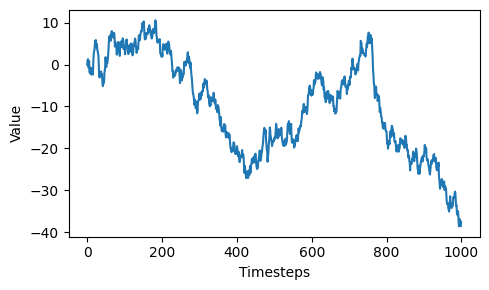

In [3]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(random_walk)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
plt.tight_layout()

## Simulating time series - stationary and non-stationary based on 'root' value

We know that for a given time series in following format: $y_t = \alpha y_{t-1} + \epsilon_t$, <br> the time series is stationary only if $| \alpha$| < 1

Let us simulate cases based on this. After that, we will test it using ADF test.

In [4]:
import numpy as np


def simulate_process(case: str, n: int) -> tuple[np.ndarray, float]:
    """
    Simulate a time series process with different autoregressive coefficients.

    Parameters
    ----------
    case : str
        Specifies the type of process:
        - 'unit'         : alpha = 1 (unit root process)
        - 'within_unit'  : |alpha| < 1 (stationary process)
        - 'outside_unit' : |alpha| > 1 (explosive process)

    n : int
     Length of the series

    Returns
    -------
    process : np.ndarray
        The generated time series of length n.
    alpha : float
        The autoregressive coefficient used in the simulation.

    Notes
    -----
    The process is defined as:
        X_{t+1} = alpha * X_t + epsilon_t
    where epsilon_t ~ N(0,1) is standard normal noise.
    """
    np.random.seed(123)  # For reproducibility

    process = np.empty(n)

    # Determine alpha based on the case
    if case == "unit":
        alpha = 1.0
        process[0] = 0.0
    elif case == "within_unit":
        # Random alpha in (-1, 1), excluding exactly -1 or 1
        alpha = np.random.uniform(-0.99, 0.99)
        process[0] = 0.0
    elif case == "outside_unit":
        # Random alpha with |alpha| > 1
        # Choose randomly positive or negative explosive value
        sign = np.random.choice([-1, 1])
        alpha = sign * np.random.uniform(1.01, 1.02)  # took a very small range for ease of visualization
        process[0] = 0.0
    else:
        raise ValueError("Invalid case. Must be 'unit', 'within_unit', or 'outside_unit'.")

    # Generate the time series
    for i in range(n - 1):  # up to 399 because we use i+1
        process[i + 1] = alpha * process[i] + np.random.standard_normal()

    return process, alpha

In [5]:
# Simulate the three cases
n = 2000
unit_process, alpha_unit = simulate_process("unit", n)
within_unit_process, alpha_within = simulate_process("within_unit", n)
outside_unit_process, alpha_outside = simulate_process("outside_unit", n)

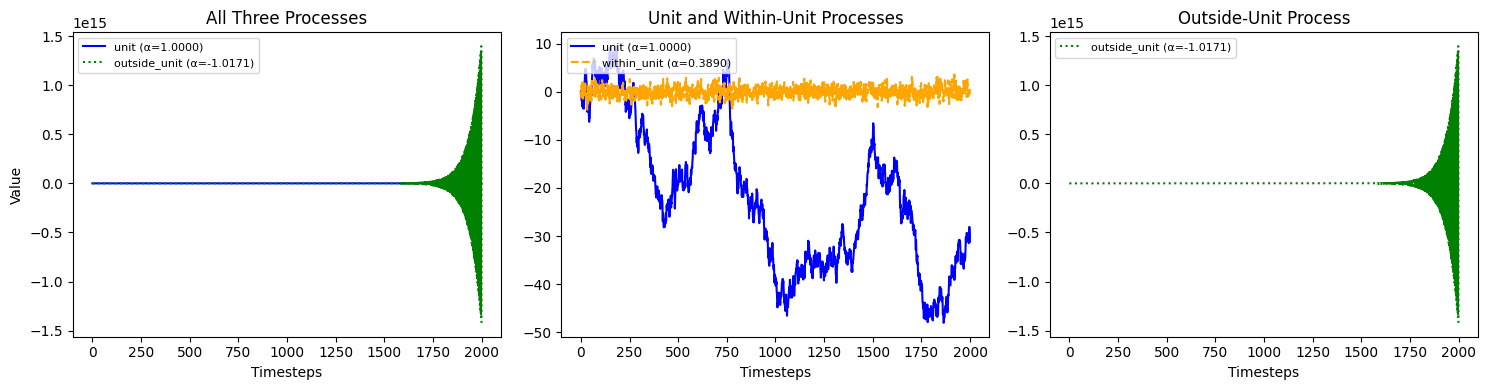

In [6]:
# Define consistent colors
color_unit = "blue"
color_within = "orange"
color_outside = "green"
# Create figure with 3 horizontal subplots, independent y-axes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. All three processes
axes[0].plot(unit_process, linestyle="-", color=color_unit, label=f"unit (α={alpha_unit:.4f})")
axes[0].plot(outside_unit_process, linestyle=":", color=color_outside, label=f"outside_unit (α={alpha_outside:.4f})")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("Value")
axes[0].set_title("All Three Processes")
axes[0].legend(loc="upper left", fontsize=8)

# 2. Only unit and within_unit
axes[1].plot(unit_process, linestyle="-", color=color_unit, label=f"unit (α={alpha_unit:.4f})")
axes[1].plot(within_unit_process, linestyle="--", color=color_within, label=f"within_unit (α={alpha_within:.4f})")
axes[1].set_xlabel("Timesteps")
axes[1].set_title("Unit and Within-Unit Processes")
axes[1].legend(loc="upper left", fontsize=8)

# 3. Only outside_unit
axes[2].plot(outside_unit_process, linestyle=":", color=color_outside, label=f"outside_unit (α={alpha_outside:.4f})")
axes[2].set_xlabel("Timesteps")
axes[2].set_title("Outside-Unit Process")
axes[2].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

I have added a separate plot for the exploding case ($|\alpha| > 1$) for visualizing all three lines clearly. 

### Plotting the mean and variance 

In [7]:
# Mean over time function
def mean_over_time(process: np.ndarray) -> np.ndarray:
    """Compute mean of the process over time (cumulative mean)."""
    mean_func = []
    for i in range(len(process)):
        mean_func.append(np.mean(process[: i + 1]))  # include current element
    return np.array(mean_func)


# Variance over time function
def var_over_time(process: np.ndarray) -> np.ndarray:
    """Compute variance of the process over time (cumulative variance)."""
    var_func = []
    for i in range(len(process)):
        var_func.append(np.var(process[: i + 1]))  # include current element
    return np.array(var_func)


# Compute mean and variance for each process
mean_unit = mean_over_time(unit_process)
mean_within = mean_over_time(within_unit_process)
mean_outside = mean_over_time(outside_unit_process)

var_unit = var_over_time(unit_process)
var_within = var_over_time(within_unit_process)
var_outside = var_over_time(outside_unit_process)

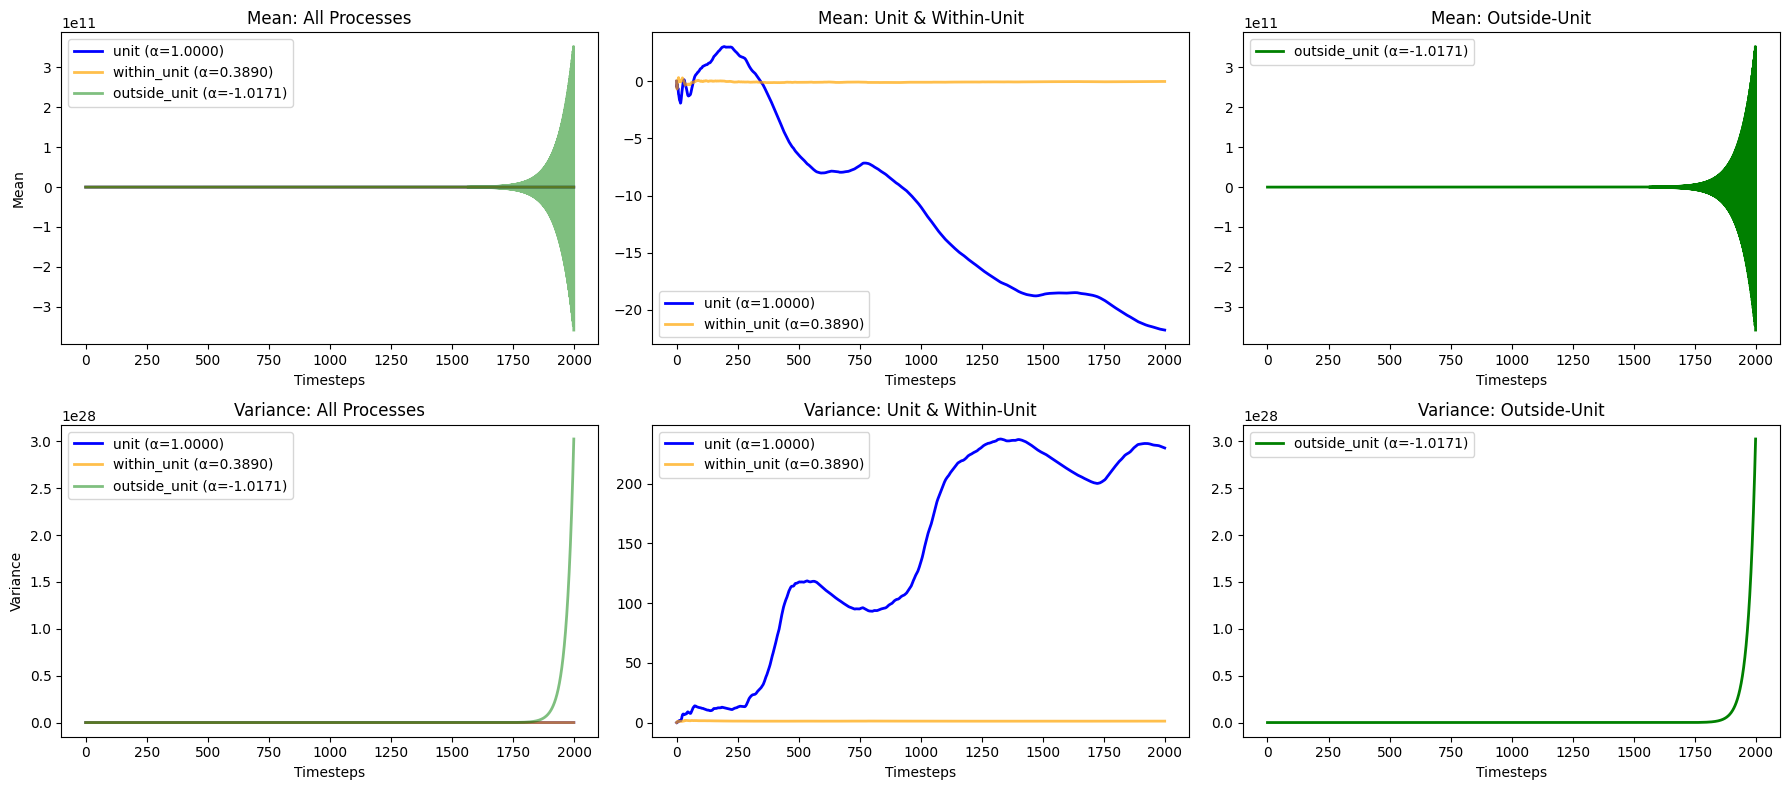

In [8]:
# Thickness and transparency settings
lw_main = 2  # main line width
alpha_main = 1.0  # fully opaque
alpha_secondary = 0.7  # slightly transparent
alpha_last = 0.5  # more transparent

# Create figure with 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# ---------------------------
# Row 1: Mean over time
# ---------------------------
# 1. All three processes
axes[0, 0].plot(mean_unit, color="blue", linewidth=lw_main, alpha=alpha_main, label=f"unit (α={alpha_unit:.4f})")
axes[0, 0].plot(mean_within, color="orange", linewidth=lw_main, alpha=alpha_secondary, label=f"within_unit (α={alpha_within:.4f})")
axes[0, 0].plot(mean_outside, color="green", linewidth=lw_main, alpha=alpha_last, label=f"outside_unit (α={alpha_outside:.4f})")
axes[0, 0].set_title("Mean: All Processes")
axes[0, 0].set_xlabel("Timesteps")
axes[0, 0].set_ylabel("Mean")
axes[0, 0].legend()

# 2. Only unit and within-unit
axes[0, 1].plot(mean_unit, color="blue", linewidth=lw_main, alpha=alpha_main, label=f"unit (α={alpha_unit:.4f})")
axes[0, 1].plot(mean_within, color="orange", linewidth=lw_main, alpha=alpha_secondary, label=f"within_unit (α={alpha_within:.4f})")
axes[0, 1].set_title("Mean: Unit & Within-Unit")
axes[0, 1].set_xlabel("Timesteps")
axes[0, 1].legend()

# 3. Only outside-unit
axes[0, 2].plot(mean_outside, color="green", linewidth=lw_main, alpha=alpha_main, label=f"outside_unit (α={alpha_outside:.4f})")
axes[0, 2].set_title("Mean: Outside-Unit")
axes[0, 2].set_xlabel("Timesteps")
axes[0, 2].legend()

# ---------------------------
# Row 2: Variance over time
# ---------------------------
# 1. All three processes
axes[1, 0].plot(var_unit, color="blue", linewidth=lw_main, alpha=alpha_main, label=f"unit (α={alpha_unit:.4f})")
axes[1, 0].plot(var_within, color="orange", linewidth=lw_main, alpha=alpha_secondary, label=f"within_unit (α={alpha_within:.4f})")
axes[1, 0].plot(var_outside, color="green", linewidth=lw_main, alpha=alpha_last, label=f"outside_unit (α={alpha_outside:.4f})")
axes[1, 0].set_title("Variance: All Processes")
axes[1, 0].set_xlabel("Timesteps")
axes[1, 0].set_ylabel("Variance")
axes[1, 0].legend()

# 2. Only unit and within-unit
axes[1, 1].plot(var_unit, color="blue", linewidth=lw_main, alpha=alpha_main, label=f"unit (α={alpha_unit:.4f})")
axes[1, 1].plot(var_within, color="orange", linewidth=lw_main, alpha=alpha_secondary, label=f"within_unit (α={alpha_within:.4f})")
axes[1, 1].set_title("Variance: Unit & Within-Unit")
axes[1, 1].set_xlabel("Timesteps")
axes[1, 1].legend()

# 3. Only outside-unit
axes[1, 2].plot(var_outside, color="green", linewidth=lw_main, alpha=alpha_main, label=f"outside_unit (α={alpha_outside:.4f})")
axes[1, 2].set_title("Variance: Outside-Unit")
axes[1, 2].set_xlabel("Timesteps")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## Test of Stationarity

In [9]:
from statsmodels.tsa.stattools import adfuller

In [10]:
ADF_result = adfuller(outside_unit_process)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -1.4970969138832486e+16
p-value: 0.0


In [11]:
# Define a helper function to run ADF and print results
def run_adf_test(process, name):
    """
    Perform Augmented Dickey-Fuller test on a time series.

    Parameters
    ----------
    process : np.ndarray
        Time series to test
    name : str
        Name of the process (for printing)
    """
    ADF_result = adfuller(process)
    adf_stat = ADF_result[0]
    p_value = ADF_result[1]

    print(f"--- {name} ---")
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Reject null hypothesis: No unit root detected → series may be stationary.\n")
    else:
        print("Fail to reject null hypothesis: Unit root may be present → series may be non-stationary.\n")


# Run ADF test on all three processes
run_adf_test(unit_process, "Unit Process (α=1)")
run_adf_test(within_unit_process, "Within-Unit Process (|α|<1)")
run_adf_test(outside_unit_process, "Outside-Unit Process (|α|>1)")

--- Unit Process (α=1) ---
ADF Statistic: -1.7345
p-value: 0.4134
Fail to reject null hypothesis: Unit root may be present → series may be non-stationary.

--- Within-Unit Process (|α|<1) ---
ADF Statistic: -28.6815
p-value: 0.0000
Reject null hypothesis: No unit root detected → series may be stationary.

--- Outside-Unit Process (|α|>1) ---
ADF Statistic: -14970969138832486.0000
p-value: 0.0000
Reject null hypothesis: No unit root detected → series may be stationary.




## ⚠️Note: 
The ADF test specifically checks for a unit root. It may **fail for explosive processes** and should not be interpreted as a general test for stationarity. It only indicates whether a unit root is likely present.

## Differencing a Random Walk and checking for its stationarity

We know that the 1st order difference of a random walk process is stationary. Let's verify that now

In [13]:
diff_random_walk = np.diff(unit_process, n=1)

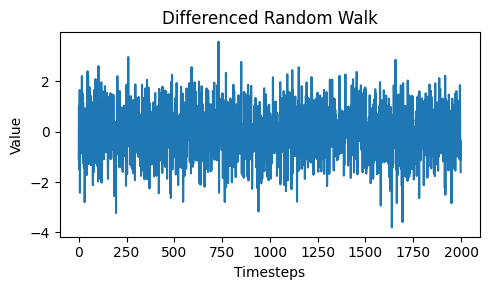

In [19]:
fig, ax = plt.subplots(figsize=(5, 3))

plt.plot(diff_random_walk)
plt.title("Differenced Random Walk")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.tight_layout()

In [20]:
run_adf_test(diff_random_walk, name="Differenced Random Walk")

--- Differenced Random Walk ---
ADF Statistic: -26.8661
p-value: 0.0000
Reject null hypothesis: No unit root detected → series may be stationary.

